# LokyStackerV10RSTSFRandom — Train & Predict Timing Across Datasets

In [1]:
import time
import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate_equal_length
from tscglue import data_loader
from tscglue.models import LokyStackerV10RSTSFRandom
from tscglue.utils import S3FileCache
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
from pathlib import Path


directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)

In [3]:
DATASETS = sorted(univariate_equal_length)
FOLDS = list(range(1))

cache = S3FileCache("s3://tsc-glue/lokystacker-timing")

In [4]:
combos = [(ds, fold) for ds in DATASETS for fold in FOLDS]
n = len(combos)

for i, (dataset, fold) in enumerate(combos, 1):
    filename = f"{dataset}_fold{fold}.parquet"

    # break

    if cache.exists(filename):
        print(f"[{i}/{n}] SKIP {dataset} fold={fold}")
        continue

    print(f"\n[{i}/{n}] {'='*50}")
    print(f"Dataset: {dataset}  fold={fold}")
    print(f"{'='*54}")

    X_train, y_train, X_test, y_test = data_loader.load_fold(dataset, fold=fold)
    n_train, n_channels, series_len = X_train.shape
    n_test = X_test.shape[0]
    n_classes = len(np.unique(y_train))
    print(f"  train={X_train.shape}  test={X_test.shape}  classes={n_classes}")

    model = LokyStackerV10RSTSFRandom(random_state=fold, n_jobs=16)

    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
    print(f"  fit:     {train_time:.2f}s")

    t0 = time.perf_counter()
    preds = model.predict(X_test)
    predict_time = time.perf_counter() - t0
    accuracy = np.mean(preds == y_test)
    print(f"  predict: {predict_time:.2f}s  accuracy={accuracy:.4f}")

    record = pl.DataFrame({
        "dataset":        [dataset],
        "fold":           [fold],
        "n_train":        [n_train],
        "n_test":         [n_test],
        "series_len":     [series_len],
        "n_classes":      [n_classes],
        "train_time_s":   [train_time],
        "predict_time_s": [predict_time],
        "accuracy":       [accuracy],
    })
    cache.add(record, filename)
    print(f"  saved → s3://tsc-glue/lokystacker-timing/{filename}")

print("\nDone.")

[1/112] SKIP ACSF1 fold=0
[2/112] SKIP Adiac fold=0
[3/112] SKIP ArrowHead fold=0
[4/112] SKIP BME fold=0
[5/112] SKIP Beef fold=0
[6/112] SKIP BeetleFly fold=0
[7/112] SKIP BirdChicken fold=0
[8/112] SKIP CBF fold=0
[9/112] SKIP Car fold=0
[10/112] SKIP Chinatown fold=0
[11/112] SKIP ChlorineConcentration fold=0
[12/112] SKIP CinCECGTorso fold=0
[13/112] SKIP Coffee fold=0
[14/112] SKIP Computers fold=0
[15/112] SKIP CricketX fold=0
[16/112] SKIP CricketY fold=0
[17/112] SKIP CricketZ fold=0
[18/112] SKIP Crop fold=0
[19/112] SKIP DiatomSizeReduction fold=0
[20/112] SKIP DistalPhalanxOutlineAgeGroup fold=0
[21/112] SKIP DistalPhalanxOutlineCorrect fold=0
[22/112] SKIP DistalPhalanxTW fold=0
[23/112] SKIP ECG200 fold=0
[24/112] SKIP ECG5000 fold=0
[25/112] SKIP ECGFiveDays fold=0
[26/112] SKIP EOGHorizontalSignal fold=0
[27/112] SKIP EOGVerticalSignal fold=0
[28/112] SKIP Earthquakes fold=0
[29/112] SKIP ElectricDevices fold=0
[30/112] SKIP EthanolLevel fold=0
[31/112] SKIP FaceAll fol

In [5]:
df = cache.read_all_parquet_cached()
print(f"Loaded {len(df)}/{len(DATASETS) * len(FOLDS)} runs\n")
print(df)

Loaded 112/112 runs

shape: (112, 9)
┌───────────────┬──────┬─────────┬────────┬───┬───────────┬──────────────┬──────────────┬──────────┐
│ dataset       ┆ fold ┆ n_train ┆ n_test ┆ … ┆ n_classes ┆ train_time_s ┆ predict_time ┆ accuracy │
│ ---           ┆ ---  ┆ ---     ┆ ---    ┆   ┆ ---       ┆ ---          ┆ _s           ┆ ---      │
│ str           ┆ i64  ┆ i64     ┆ i64    ┆   ┆ i64       ┆ f64          ┆ ---          ┆ f64      │
│               ┆      ┆         ┆        ┆   ┆           ┆              ┆ f64          ┆          │
╞═══════════════╪══════╪═════════╪════════╪═══╪═══════════╪══════════════╪══════════════╪══════════╡
│ ACSF1         ┆ 0    ┆ 100     ┆ 100    ┆ … ┆ 10        ┆ 98.05387     ┆ 87.43913     ┆ 0.94     │
│ Adiac         ┆ 0    ┆ 390     ┆ 391    ┆ … ┆ 37        ┆ 105.349981   ┆ 107.952906   ┆ 0.867008 │
│ ArrowHead     ┆ 0    ┆ 36      ┆ 175    ┆ … ┆ 3         ┆ 52.947939    ┆ 69.232668    ┆ 0.845714 │
│ BME           ┆ 0    ┆ 30      ┆ 150    ┆ … ┆ 3     

In [6]:
train_ips = 1 / (df["train_time_s"] / df["n_train"]).mean()
pred_ips  = 1 / (df["predict_time_s"] / df["n_test"]).mean()

print(f"Mean train time:    {df['train_time_s'].mean() / 60:.2f} min  ({train_ips:.1f} train instances/s")
print(f"Mean predict time:  {df['predict_time_s'].mean() / 60:.2f} min  ({pred_ips:.1f} test instances/s)")
print(f"Mean total time:    {(df['train_time_s'] + df['predict_time_s']).mean() / 60:.2f} min")
print()
print(f"Total train time:   {df['train_time_s'].sum() / 60:.2f} min  ({df['train_time_s'].sum() / 3600:.2f} h)")
print(f"Total predict time: {df['predict_time_s'].sum() / 60:.2f} min  ({df['predict_time_s'].sum() / 3600:.2f} h)")
print(f"Total time:         {(df['train_time_s'] + df['predict_time_s']).sum() / 60:.2f} min  ({(df['train_time_s'] + df['predict_time_s']).sum() / 3600:.2f} h)")


Mean train time:    2.16 min  (1.5 train instances/s
Mean predict time:  2.72 min  (2.8 test instances/s)
Mean total time:    4.89 min

Total train time:   242.28 min  (4.04 h)
Total predict time: 305.02 min  (5.08 h)
Total time:         547.30 min  (9.12 h)


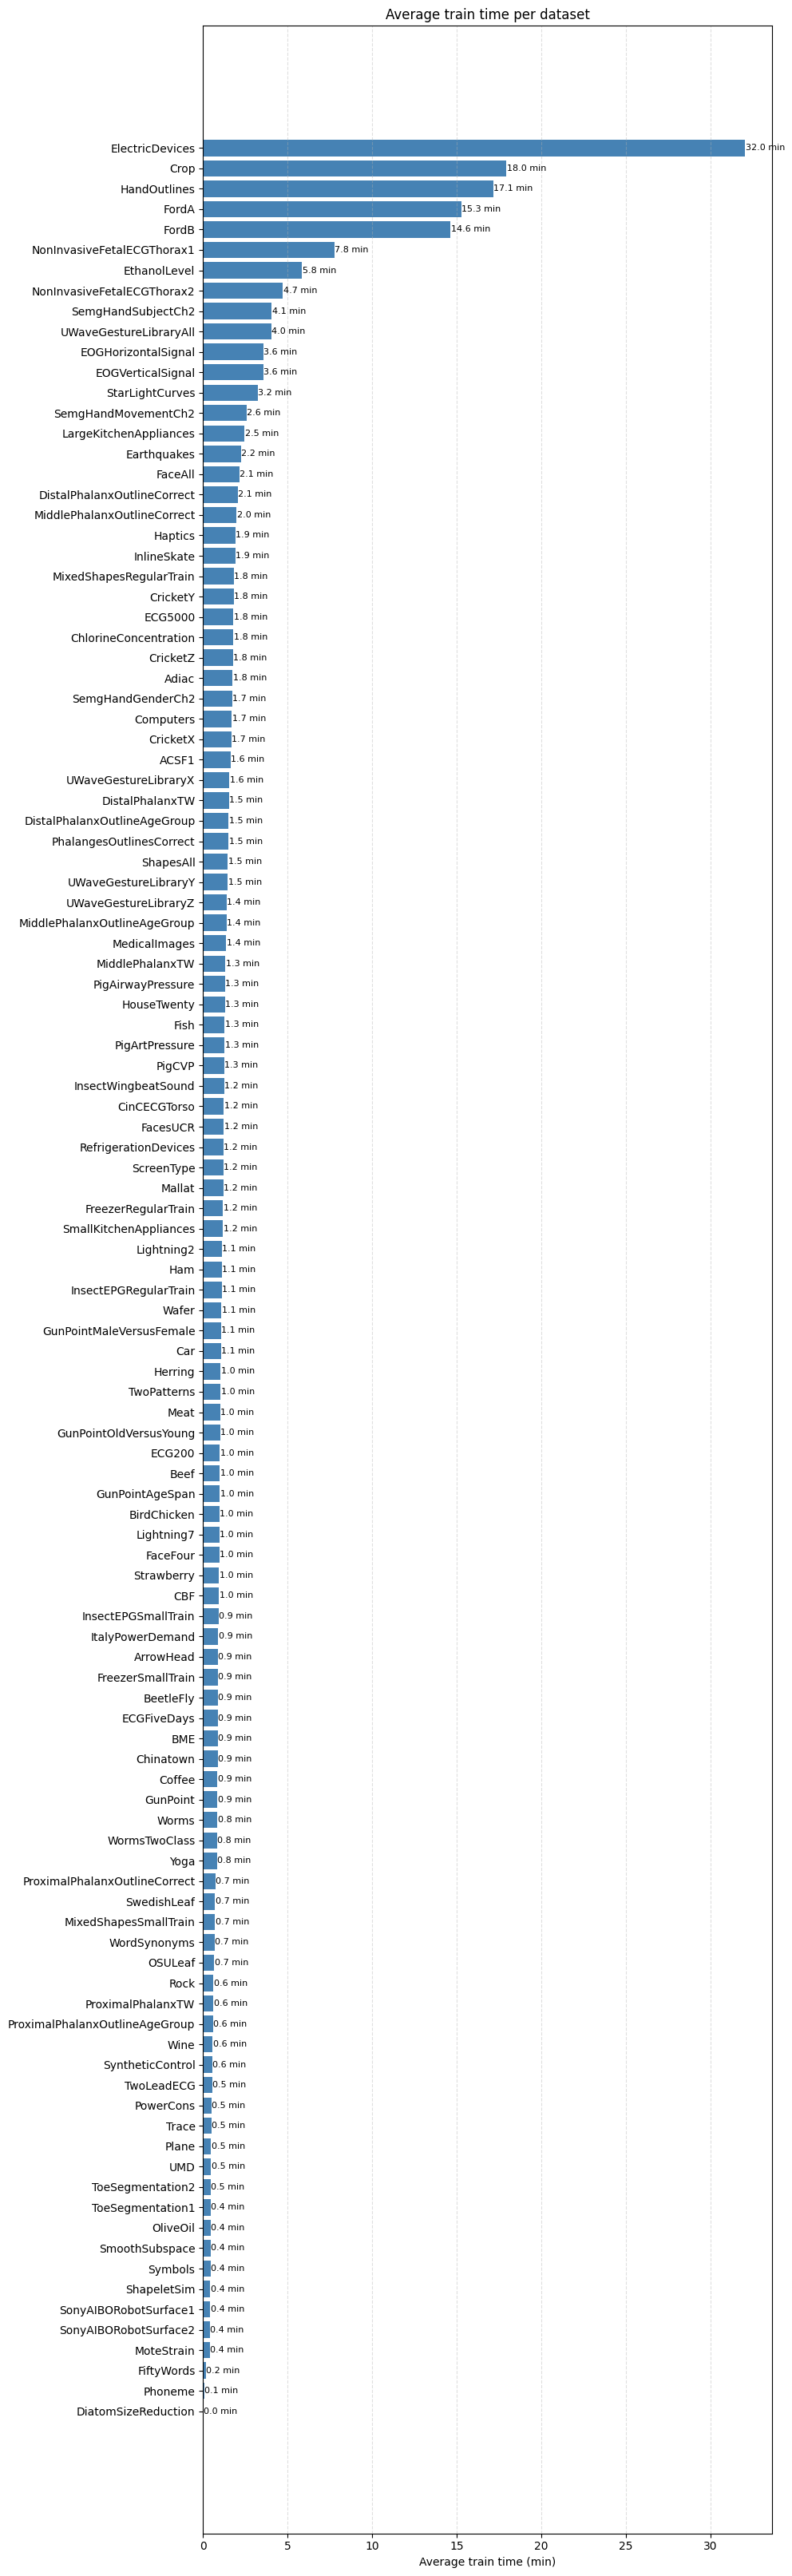

In [7]:
avg_train = (
    df.group_by("dataset")
    .agg(pl.col("train_time_s").mean().alias("avg_train_time_s"))
    .sort("avg_train_time_s", descending=True)
)

fig, ax = plt.subplots(figsize=(10, len(avg_train) * 0.28 + 1))
ax.barh(avg_train["dataset"], avg_train["avg_train_time_s"] / 60, color="steelblue")
ax.set_xlabel("Average train time (min)")
ax.set_title("Average train time per dataset")
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)
for i, (name, val) in enumerate(zip(avg_train["dataset"], avg_train["avg_train_time_s"])):
    ax.text(val / 60 + 0.02, i, f"{val/60:.1f} min", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{directory}/avg-train-time-per-dataset.pdf", bbox_inches="tight", pad_inches=0)
plt.show()


## Plots — dataset size & series length vs timing

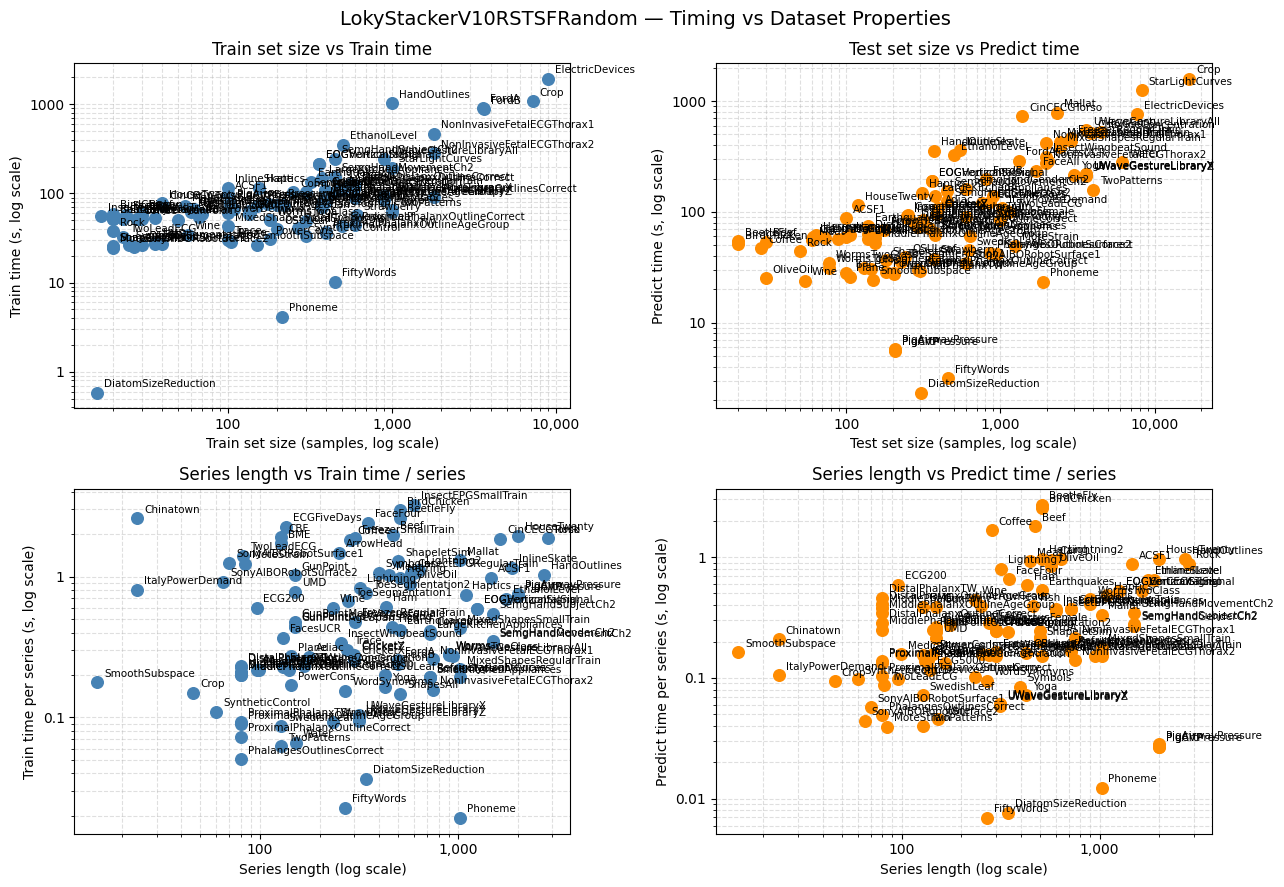

In [8]:


df = cache.read_all_parquet_cached()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("LokyStackerV10RSTSFRandom — Timing vs Dataset Properties", fontsize=14)

def scatter_with_labels(ax, x, y, labels, xlabel, ylabel, title, color):
    ax.scatter(x, y, color=color, s=70, zorder=3)
    for xi, yi, lbl in zip(x, y, labels):
        ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(5, 4), fontsize=7.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:,.0f}" if v >= 1 else f"{v:g}"))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# Row 1: total time vs dataset size
scatter_with_labels(
    axes[0, 0], df["n_train"], df["train_time_s"], df["dataset"],
    "Train set size (samples, log scale)", "Train time (s, log scale)",
    "Train set size vs Train time", "steelblue",
)
scatter_with_labels(
    axes[0, 1], df["n_test"], df["predict_time_s"], df["dataset"],
    "Test set size (samples, log scale)", "Predict time (s, log scale)",
    "Test set size vs Predict time", "darkorange",
)

# Row 2: per-series time vs series length
train_time_per_series  = df["train_time_s"]   / df["n_train"]
predict_time_per_series = df["predict_time_s"] / df["n_test"]

scatter_with_labels(
    axes[1, 0], df["series_len"], train_time_per_series, df["dataset"],
    "Series length (log scale)", "Train time per series (s, log scale)",
    "Series length vs Train time / series", "steelblue",
)
scatter_with_labels(
    axes[1, 1], df["series_len"], predict_time_per_series, df["dataset"],
    "Series length (log scale)", "Predict time per series (s, log scale)",
    "Series length vs Predict time / series", "darkorange",
)

plt.tight_layout()
plt.savefig(f"{directory}/train-inference-time.pdf", bbox_inches='tight', pad_inches=0)

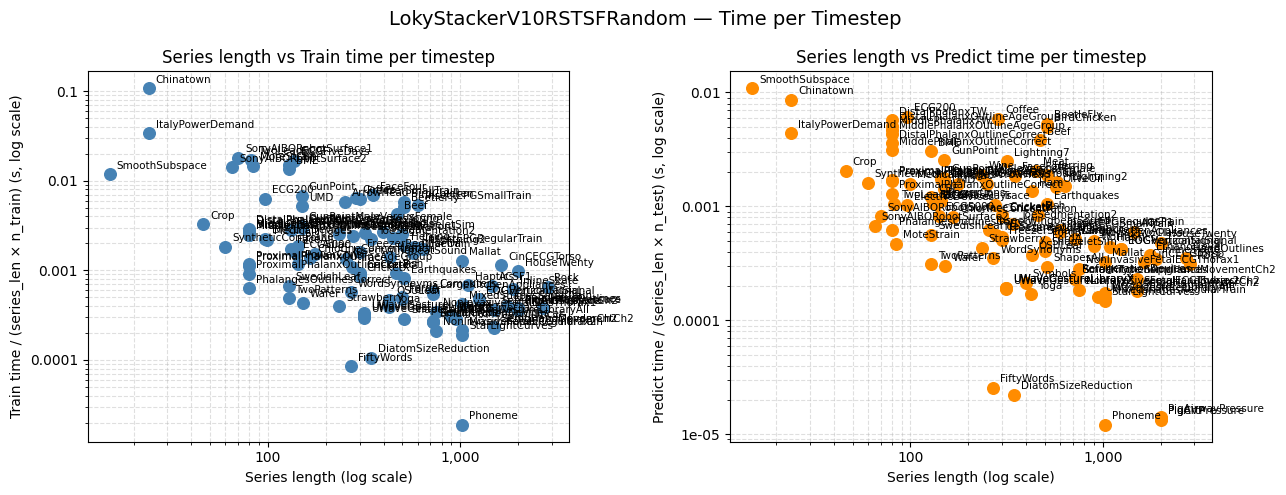

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("LokyStackerV10RSTSFRandom — Time per Timestep", fontsize=14)

train_time_per_ts  = df["train_time_s"]   / (df["series_len"] * df["n_train"])
predict_time_per_ts = df["predict_time_s"] / (df["series_len"] * df["n_test"])

scatter_with_labels(
    axes[0], df["series_len"], train_time_per_ts, df["dataset"],
    "Series length (log scale)", "Train time / (series_len × n_train) (s, log scale)",
    "Series length vs Train time per timestep", "steelblue",
)
scatter_with_labels(
    axes[1], df["series_len"], predict_time_per_ts, df["dataset"],
    "Series length (log scale)", "Predict time / (series_len × n_test) (s, log scale)",
    "Series length vs Predict time per timestep", "darkorange",
)

plt.tight_layout()
plt.savefig(f"{directory}/train-inference-time-per-timestep.pdf", bbox_inches='tight', pad_inches=0)


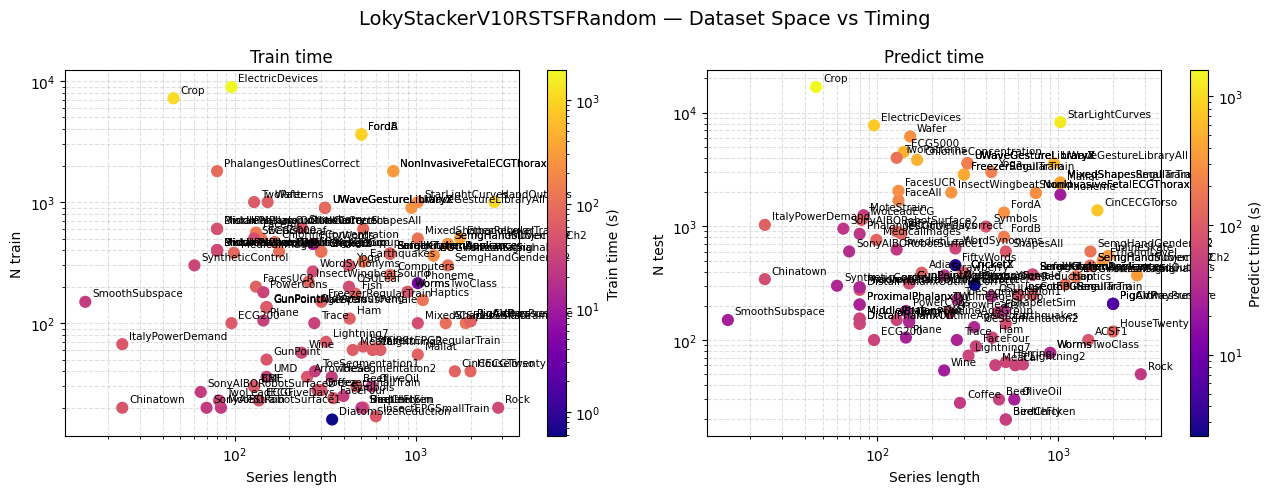

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("LokyStackerV10RSTSFRandom — Dataset Space vs Timing", fontsize=14)

for ax, time_col, title, label in [
    (axes[0], "train_time_s",   "Train time",   "Train time (s)"),
    (axes[1], "predict_time_s", "Predict time", "Predict time (s)"),
]:
    n = df["n_train"] if time_col == "train_time_s" else df["n_test"]
    sc = ax.scatter(
        df["series_len"], n,
        c=df[time_col], cmap="plasma", norm=plt.matplotlib.colors.LogNorm(),
        s=60, zorder=3,
    )
    for xi, yi, lbl in zip(df["series_len"], n, df["dataset"]):
        ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(5, 4), fontsize=7.5)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_xlabel("Series length")
    ax.set_ylabel("N train" if time_col == "train_time_s" else "N test")
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{directory}/train-inference-time-heatmap.pdf", bbox_inches='tight', pad_inches=0)


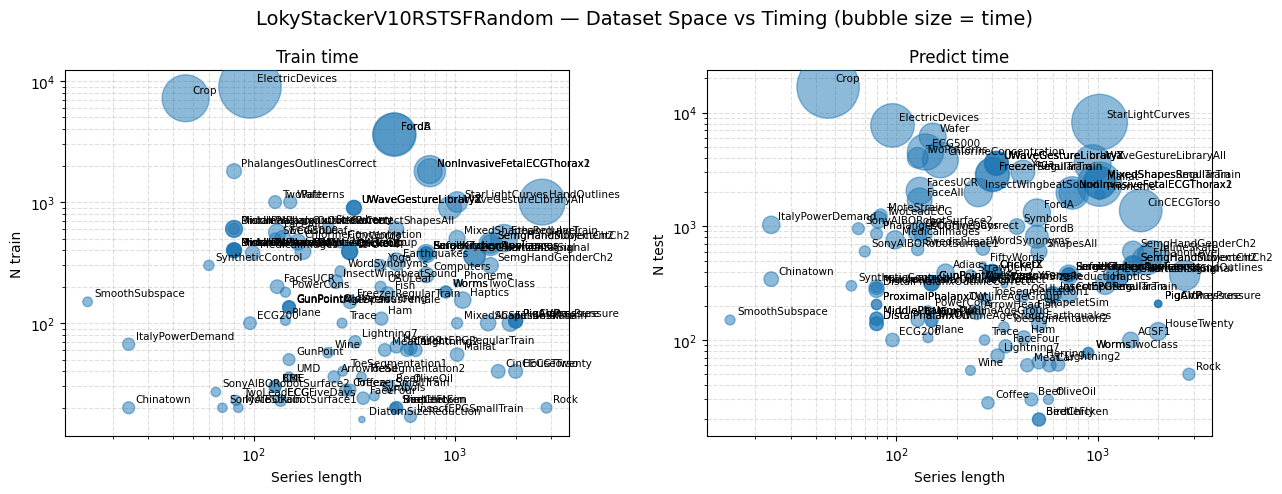

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("LokyStackerV10RSTSFRandom — Dataset Space vs Timing (bubble size = time)", fontsize=14)

for ax, time_col, title in [
    (axes[0], "train_time_s",   "Train time"),
    (axes[1], "predict_time_s", "Predict time"),
]:
    n = df["n_train"] if time_col == "train_time_s" else df["n_test"]
    t = df[time_col].to_numpy()
    sizes = (t / t.max()) * 2000 + 20

    sc = ax.scatter(df["series_len"], n, s=sizes, alpha=0.5, zorder=3)
    for xi, yi, lbl in zip(df["series_len"], n, df["dataset"]):
        ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(5, 4), fontsize=7.5)
    ax.set_xlabel("Series length")
    ax.set_ylabel("N train" if time_col == "train_time_s" else "N test")
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{directory}/train-inference-time-bubble.pdf", bbox_inches='tight', pad_inches=0)


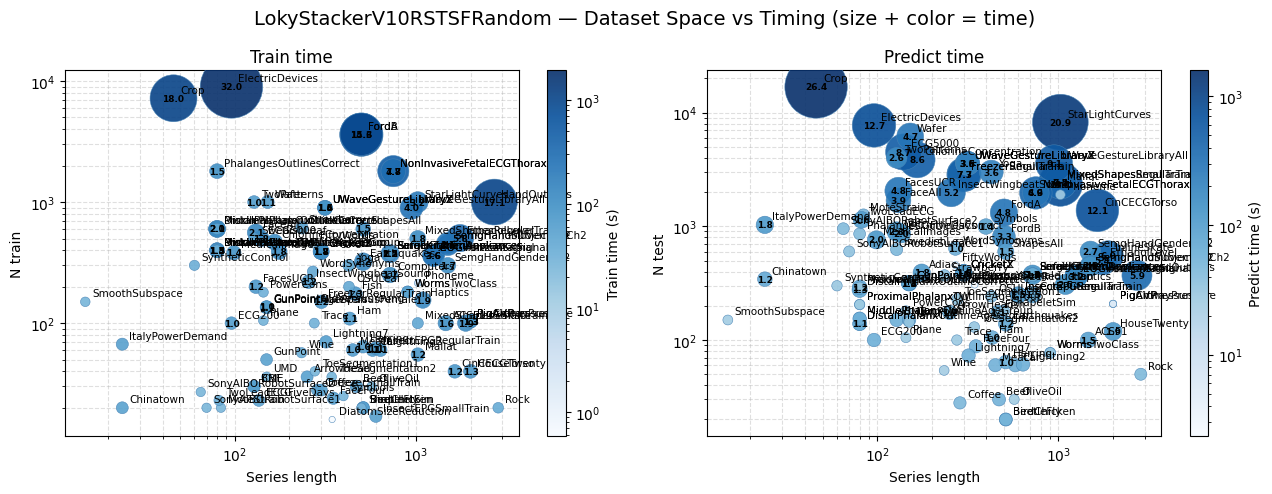

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("LokyStackerV10RSTSFRandom — Dataset Space vs Timing (size + color = time)", fontsize=14)

for ax, time_col, title, ylabel in [
    (axes[0], "train_time_s",   "Train time",   "N train"),
    (axes[1], "predict_time_s", "Predict time", "N test"),
]:
    n = df["n_train"] if time_col == "train_time_s" else df["n_test"]
    t = df[time_col].to_numpy()
    sizes = (t / t.max()) * 2000 + 20

    sc = ax.scatter(
        df["series_len"], n, s=sizes,
        c=t, cmap="Blues", norm=plt.matplotlib.colors.LogNorm(),
        alpha=0.9, edgecolors="steelblue", linewidths=0.4, zorder=3,
    )
    for xi, yi, lbl, ti in zip(df["series_len"], n, df["dataset"], t):
        ax.annotate(lbl, (xi, yi), textcoords="offset points", xytext=(5, 4), fontsize=7.5)
        if ti > 60:
            ax.annotate(
                f"{ti/60:.1f}", (xi, yi),
                ha="center", va="center", fontsize=6.5, fontweight="bold", color="black", zorder=4,
            )
    plt.colorbar(sc, ax=ax, label=f"{title} (s)")
    ax.set_xlabel("Series length")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{directory}/train-inference-time-bubble-color.pdf", bbox_inches='tight', pad_inches=0)
